# Fase 2 — Descrizione e comprensione del dataset

Obiettivo: svolgere una prima analisi del dataset *Customer Churn* per comprenderne struttura, distribuzioni, qualità, limiti e possibili problemi.

Questa fase produce:
- statistiche descrittive;
- controllo missing values e duplicati;
- analisi di class imbalance;
- controllo outlier;
- 8 domande/ipotesi;
- 3 riflessioni critiche sui dati.


In [ ]:
#Import Librerie

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

In questo primo blocco importiamo le librerie necessarie per l'analisi: `pandas` e `numpy` per la gestione dei dati, `matplotlib` e `seaborn` per le visualizzazioni. Impostiamo anche uno stile grafico uniforme per rendere i grafici più leggibili.

**Nove Domande per analisi descrittiva**


1.   Quali sono le dimensioni del dataset (righe e colonne) e i tipi di variabili presenti?
2.   Esistono record duplicati o identificativi utente ripetuti che potrebbero inficiare l'analisi?
3. Qual è la presenza e la percentuale di valori mancanti (missing values) per ogni singola colonna?
4. Come si distribuisce la variabile target `Churn`? Siamo in presenza di un forte sbilanciamento delle classi (class imbalance)?
5. Quali sono i valori di tendenza centrale e dispersione delle metriche di utilizzo del servizio (es. durata della sottoscrizione, chiamate al servizio clienti)?
6. Qual è la cardinalità delle variabili categoriche (es. tipo di contratto, metodo di pagamento)? Ci sono troppe categorie distinte?
7. Ci sono anomalie o valori estremi (outlier) nei dati numerici che non hanno senso logico (es. età negative, spese pari a zero)?
8. Le variabili numeriche presentano ordini di grandezza molto diversi tra loro (es. età vs entrate annuali) richiedendo una futura scalatura?
9. Esistono variabili con varianza vicina allo zero (ovvero colonne in cui quasi tutti i clienti hanno lo stesso identico valore) che non portano informazione predittiva?




**DOMANDA 1**

In [ ]:
#Caricamento Dataset

df_raw = pd.read_csv("/content/sample_data/Customer_Churn.csv")

print("Numero righe e colonne:", df_raw.shape)

display(df_raw.head())

Numero righe e colonne: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
#Struttura del Dataset

df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Il dataset viene caricato correttamente e contiene **7043 osservazioni** e **21 colonne**. Le prime righe permettono di osservare la struttura generale: sono presenti variabili anagrafiche, informazioni sui servizi acquistati, dati economici e la variabile target `Churn`, che indica se il cliente ha abbandonato il servizio.

La funzione `info()` consente di controllare il numero di valori non nulli e il tipo di dato di ciascuna colonna: la maggior parte delle variabili è di tipo `object`, quindi categorica; le variabili numeriche principali sono `SeniorCitizen`  (questa rappresenta in realtà una variabile categoriale binaria, che però risulta già essere stata codificata come una numerica con valori 0/1), `tenure` e `MonthlyCharges`. La colonna `TotalCharges`, pur rappresentando un importo, risulta inizialmente di tipo testuale: questo segnala un possibile problema di qualità del dato da correggere.

**Domanda 2**

In [ ]:
#Controllo Duplicati

duplicati_totali = df_raw.duplicated().sum()
duplicati_customerID = df_raw["customerID"].duplicated().sum()

print("Duplicati totali:", duplicati_totali)
print("Duplicati customerID:", duplicati_customerID)

Duplicati totali: 0
Duplicati customerID: 0


Il controllo mostra che non sono presenti righe duplicate e che anche `customerID` non contiene duplicati, questo è un buon segnale di qualità del dataset: ogni riga rappresenta un cliente distinto e non ci sono osservazioni ripetute da rimuovere.

**Domanda 3**

In [ ]:
#Controllo Valori Mancanti

print("Missing values standard:")
display(df_raw.isnull().sum())

print("Missing values nascosti, cioè celle vuote o contenenti solo spazi:")

hidden_missing_summary = {}

for col in df_raw.columns:
    hidden_missing = (df_raw[col].astype(str).str.strip() == "").sum()
    hidden_missing_summary[col] = hidden_missing

    if hidden_missing > 0:
        print(col, ":", hidden_missing)

hidden_missing_table = pd.DataFrame({
    "colonna": list(hidden_missing_summary.keys()),
    "missing_nascosti": list(hidden_missing_summary.values())
})

display(hidden_missing_table[hidden_missing_table["missing_nascosti"] > 0])

Missing values standard:


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Missing values nascosti, cioè celle vuote o contenenti solo spazi:
TotalCharges : 11


,colonna,missing_nascosti
19,TotalCharges,11


 Il controllo dei missing values standard non rileva valori mancanti. Tuttavia, il controllo dei missing nascosti mostra che `TotalCharges` contiene **11 celle vuote o composte solo da spazi**; questo passaggio è importante perché alcuni valori mancanti non vengono riconosciuti automaticamente come `NaN` se sono salvati come stringhe vuote.

 Procediamo dunque alla pulizia della variabile.


In [ ]:
#Pulizia Variabile TotalCharges

df = df_raw.copy()

print("Tipo iniziale di TotalCharges:", df["TotalCharges"].dtype)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

missing_totalcharges = df["TotalCharges"].isna().sum()
print("Valori mancanti in TotalCharges dopo conversione:", missing_totalcharges)

righe_prima = df.shape[0]
df = df.dropna(subset=["TotalCharges"])
righe_dopo = df.shape[0]
righe_rimosse = righe_prima - righe_dopo

print("Righe prima della rimozione:", righe_prima)
print("Righe dopo la rimozione:", righe_dopo)
print("Righe rimosse:", righe_rimosse)

print("\nMissing values dopo la pulizia:")
display(df.isnull().sum())

Tipo iniziale di TotalCharges: object
Valori mancanti in TotalCharges dopo conversione: 11
Righe prima della rimozione: 7043
Righe dopo la rimozione: 7032
Righe rimosse: 11

Missing values dopo la pulizia:


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



`TotalCharges` viene convertita da variabile testuale a variabile numerica. Durante la conversione, gli 11 valori vuoti diventano `NaN` e vengono rimossi, e il dataset passa quindi da **7043** a **7032 osservazioni**; la perdita di dati è minima, quindi la rimozione di queste righe non dovrebbe alterare in modo significativo l'analisi.

**Domanda 4**

In [ ]:
#Distribuzione Variabile Target Churn

churn_counts = df["Churn"].value_counts()
churn_percent = round(df["Churn"].value_counts(normalize=True) * 100, 2)

print("Conteggi:")
display(churn_counts)

print("\nPercentuali:")
display(churn_percent)

Conteggi:


,count
Churn,
No,5163
Yes,1869



Percentuali:


,proportion
Churn,
No,73.42
Yes,26.58


La variabile target `Churn` è sbilanciata: il 73,42% dei clienti non ha abbandonato il servizio, mentre il 26,58% lo ha abbandonato. Questo è un aspetto importante perché nella fase di modellazione l'accuracy da sola potrebbe essere poco informativa; sarà quindi necessario valutare i modelli anche con precision, recall e F1-score.

**Domanda 5**

In [ ]:
#Statistiche Descrittive

display(df[["tenure", "MonthlyCharges", "TotalCharges"]].describe().T)

statistiche_da_commentare = pd.DataFrame({
    "statistica": [
        "Numero osservazioni",
        "Media tenure",
        "Mediana tenure",
        "Media MonthlyCharges",
        "Media TotalCharges",
        "Deviazione standard MonthlyCharges",
        "Valore minimo tenure",
        "Valore massimo tenure"
    ],
    "valore": [
        df.shape[0],
        round(df["tenure"].mean(), 2),
        round(df["tenure"].median(), 2),
        round(df["MonthlyCharges"].mean(), 2),
        round(df["TotalCharges"].mean(), 2),
        round(df["MonthlyCharges"].std(), 2),
        df["tenure"].min(),
        df["tenure"].max()
    ]
})

display(statistiche_da_commentare)

,count,mean,std,min,25%,50%,75%,max
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


,statistica,valore
0,Numero osservazioni,7032.00
1,Media tenure,32.42
2,Mediana tenure,29.00
3,Media MonthlyCharges,64.80
4,Media TotalCharges,2283.30
5,Deviazione standard MonthlyCharges,30.09
6,Valore minimo tenure,1.00
7,Valore massimo tenure,72.00


  Le statistiche descrittive mostrano che il dataset ripulito dai valori vuoti di `TotalCharges` contiene **7032 clienti**. La permanenza media (`tenure`) è circa **32,42 mesi**, mentre la mediana è **29 mesi**. La spesa mensile media (`MonthlyCharges`) è circa **64,80**, mentre la spesa totale media (`TotalCharges`) è circa **2283,30**. Il valore minimo di `tenure` è **1 mese** e il massimo è **72 mesi**, indicando clienti sia molto recenti sia di lunga durata.

**Domanda 6**

In [ ]:
import pandas as pd

# Cardinalità

categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols_no_id = [col for col in categorical_cols if col != 'customerID']

cardinalita = df[categorical_cols_no_id].nunique().sort_values(ascending=False)

df_cardinalita = pd.DataFrame({
    "Variabile Categorica": cardinalita.index,
    "Numero Categorie Uniche (Cardinalità)": cardinalita.values,
    "Esempio di Valori": [df[col].unique()[:3] for col in cardinalita.index] # Mostra i primi 3 valori come esempio
})

display(df_cardinalita)

,Variabile Categorica,Numero Categorie Uniche (Cardinalità),Esempio di Valori
0,PaymentMethod,4,"[Electronic check, Mailed check, Bank transfer..."
1,OnlineBackup,3,"[Yes, No, No internet service]"
2,InternetService,3,"[DSL, Fiber optic, No]"
3,OnlineSecurity,3,"[No, Yes, No internet service]"
4,TechSupport,3,"[No, Yes, No internet service]"
5,StreamingTV,3,"[No, Yes, No internet service]"
6,DeviceProtection,3,"[No, Yes, No internet service]"
7,MultipleLines,3,"[No phone service, No, Yes]"
8,StreamingMovies,3,"[No, Yes, No internet service]"
9,Contract,3,"[Month-to-month, One year, Two year]"


L'analisi mostra che tutte le variabili categoriche esaminate presentano una bassa cardinalità (compresa generalmente tra 2 e 4 categorie uniche); non ci sono variabili con troppe categorie distinte.

**Domanda 7**

In [ ]:
#Anomalie o Valori Estremi
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
outliers_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25) # Primo quartile (25°)
    Q3 = df[col].quantile(0.75) # Terzo quartile (75°)
    IQR = Q3 - Q1               # Intervallo Interquartile

    limite_inferiore = Q1 - 1.5 * IQR
    limite_superiore = Q3 + 1.5 * IQR

    num_outliers = df[(df[col] < limite_inferiore) | (df[col] > limite_superiore)].shape[0]
    percentuale_outliers = (num_outliers / df.shape[0]) * 100

    outliers_summary.append({
        "Variabile": col,
        "Min rilevato": df[col].min(),
        "Max rilevato": df[col].max(),
        "Limite Inf (IQR)": round(limite_inferiore, 2),
        "Limite Sup (IQR)": round(limite_superiore, 2),
        "N. Outlier": num_outliers,
        "% Outlier": round(percentuale_outliers, 2)
    })

df_outliers = pd.DataFrame(outliers_summary)
display(df_outliers)

,Variabile,Min rilevato,Max rilevato,Limite Inf (IQR),Limite Sup (IQR),N. Outlier,% Outlier
0,tenure,1.00,72.00,-60.00,124.00,0,0.0
1,MonthlyCharges,18.25,118.75,-45.82,171.27,0,0.0
2,TotalCharges,18.80,8684.80,-4688.48,8884.67,0,0.0


Abbiamo applicato il metodo dell'Intervallo Interquartile (IQR) per cercare eventuali outlier (valori anomali); il risultato mostra che nelle tre variabili numeriche il numero di outlier è pari a 0. L'assenza di outlier dimostra che il dataset non ha errori di battitura o di inserimento manuale. I limiti minimi teorici sono negativi perché i dati sono molto concentrati vicino allo zero; nella realtà, il minimo logico si ferma a zero, quindi è impossibile avere outlier inferiori.
Questo è un ottimo punto di partenza per la Fase di modellazione dato che per molti modelli valori anomali sballano i risultati.

**Domanda 8**

In [ ]:
#Ordini di Grandezza
scala_summary = []

for col in numeric_cols:
    min_val = df[col].min()
    max_val = df[col].max()
    scala_summary.append({
        "Variabile": col,
        "Valore Minimo": min_val,
        "Valore Massimo": max_val,
        "Ordine di Grandezza (Range)": round(max_val - min_val, 2)
    })

df_scala = pd.DataFrame(scala_summary)
display(df_scala)

,Variabile,Valore Minimo,Valore Massimo,Ordine di Grandezza (Range)
0,tenure,1.00,72.00,71.0
1,MonthlyCharges,18.25,118.75,100.5
2,TotalCharges,18.80,8684.80,8666.0


La tabella evidenzia una netta disparità negli ordini di grandezza delle feature numeriche: mentre la variabile tenure spazia da un minimo di 1 a un massimo di 72 mesi, la variabile TotalCharges si estende su una scala sensibilmente più ampia, superando gli 8.000 dollari.

Questa differenza può influenzare alcuni algoritmi di machine learning, in particolare quelli basati sulle distanze, come k-NN, e modelli come la Regressione Logistica. Per questo motivo, prima della modellazione verrà applicata una procedura di feature scaling tramite StandardScaler, così da rendere le variabili numeriche più confrontabili tra loro.

**Domanda 9**

In [ ]:
#Feature e Varianza
varianze = df[numeric_cols].var()

df_varianza = pd.DataFrame({
    "Variabile Numerica": varianze.index,
    "Varianza Calcolata": np.round(varianze.values, 4),
    "Stato Feature": ["Varianza Adeguata (Mantenere)" if v > 0.1 else "Bassa Varianza (Rischio)" for v in varianze.values]
}).sort_values(by="Varianza Calcolata")

display(df_varianza)

,Variabile Numerica,Varianza Calcolata,Stato Feature
0,tenure,6.024698e+02,Varianza Adeguata (Mantenere)
1,MonthlyCharges,9.051658e+02,Varianza Adeguata (Mantenere)
2,TotalCharges,5.138252e+06,Varianza Adeguata (Mantenere)


Tutte le variabili numeriche analizzate presentano una varianza ampiamente superiore allo zero; in altre parole, i clienti non hanno tutti gli stessi valori di `tenure`, `MonthlyCharges` e `TotalCharges`.

**RIFLESSIONI CRITICHE SUI DATI**


1. La natura dei missing values in `TotalCharges`: l'analisi della qualità ha evidenziato che i valori mancanti non erano errori casuali del database, ma anomalie legate a nuovi clienti con `tenure = 0`. La scelta di escludere queste osservazioni (pari a meno dello 0.2% del totale) si è rivelata la più rigorosa dal punto di vista scientifico, poiché l'imputazione avrebbe introdotto un bias ingiustificato.
2. L'impatto del forte sbilanciamento delle classi: la distribuzione della variabile target `Churn` mostra un forte squilibrio (approssimativamente 74% vs 26%). Questa asimmetria rappresenta un limite critico per l'addestramento dei modelli nella Fase 4, poiché gli algoritmi tenderanno naturalmente a massimizzare l'accuratezza predicendo la classe maggioritaria; questo ci induce fin da ora ad abbandonare l'Accuracy come metrica principale di valutazione nella Fase 5, preferendo l'F1-Score e la Recall.
3. L'eterogeneità delle scale numeriche: i dati presentano range e ordini di grandezza fortemente disallineati. Poiché modelli come la Regressione Logistica o il k-NN risentono pesantemente della scala dei dati, emerge la necessità critica di pianificare una fase di feature scaling (standardizzazione) nella Fase 4, per evitare che le variabili con valori più alti dominino matematicamente il calcolo rispetto a metriche espresse su scale ridotte.

In [ ]:
# Salvataggio Dataset Pulito
df.to_csv("sample_data/Customer_Churn_clean.csv", index=False)

print(f"Dimensioni finali del dataset salvato: {df.shape[0]} righe e {df.shape[1]} colonne.")
print("FASE 2 COMPLETATA")

Dimensioni finali del dataset salvato: 7032 righe e 21 colonne.
FASE 2 COMPLETATA


**CONCLUSIONI**

In questa fase abbiamo analizzato la struttura e la qualità del dataset, definendone la struttura, controllando duplicati, missing values, anomalie di formattazione, outlier e distribuzione della variabile target; in particolare, è stato corretto il problema della variabile `TotalCharges`, che conteneva valori vuoti non riconosciuti inizialmente come missing values.

Le analisi descrittive hanno fornito una prima panoramica del dataset, ma non sono sufficienti per comprendere in modo approfondito le relazioni tra le variabili e il fenomeno del churn. Per questo motivo, nella Fase 3 l’analisi verrà approfondita attraverso grafici e confronti tra gruppi di clienti, con l’obiettivo di individuare quali caratteristiche risultano maggiormente associate all’abbandono del servizio.



# Fase 3 — Analisi esplorativa e visualizzazione

**Obiettivo della fase:** capire e comunicare le relazioni tra le feature, soprattutto rispetto alla variabile target `Churn`.


## Requisiti della Fase 3

In questa fase vengono soddisfatti i requisiti richiesti dal progetto:

- almeno **4 grafici diversi**;
- almeno **4 domande/ipotesi**;
- almeno **2 confronti tra variabili, gruppi o classi**;
- attenzione particolare alle relazioni tra feature e target `Churn`.

Le visualizzazioni principali utilizzate sono: **barplot**, **boxplot**, **violin plot** e **heatmap**.

In [ ]:
#Import Librerie e Caricamento Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

df = pd.read_csv("/content/sample_data/Customer_Churn_clean.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"])

print("Dimensioni dataset dopo pulizia:", df.shape)
df.head()

Dimensioni dataset dopo pulizia: (7032, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Il dataset viene caricato e si applica la stessa pulizia essenziale già svolta nella Fase 2: la variabile `TotalCharges` viene convertita in formato numerico e vengono rimosse le righe in cui questa conversione produce valori mancanti. In questo modo la Fase 3 lavora su un dataset coerente e pronto per l'analisi esplorativa.


## Domande / ipotesi della Fase 3

Le analisi seguenti sono guidate da quattro domande principali:

1. **Il tipo di contratto influenza il rischio di abbandono?**  
   Ipotesi: i clienti con contratto mensile (`Month-to-month`) hanno un tasso di churn più alto.

2. **I clienti con tenure più bassa sono più propensi al churn?**  
   Ipotesi: i clienti più recenti sono meno fidelizzati e abbandonano più frequentemente.

3. **I clienti con spese mensili più alte presentano maggiore probabilità di churn?**  
   Ipotesi: un costo mensile più elevato può essere associato a maggiore abbandono.

4. **L'assenza di servizi di supporto è associata a un churn più elevato?**  
   Ipotesi: i clienti senza `TechSupport` e `OnlineSecurity` hanno un tasso di churn maggiore.

In [ ]:
#Funzione per calcolare il Tasso di Churn

def churn_rate_table(data, feature):
    '''
    Calcola il tasso di churn percentuale per ogni categoria di una variabile.
    Il target Churn è ancora in formato testuale: Yes / No.
    '''
    table = (
        data.groupby(feature)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
        .round(2)
        .reset_index()
    )
    table.columns = [feature, "Churn rate (%)"]
    return table

Per confrontare correttamente gruppi diversi non basta contare quanti clienti hanno abbandonato: gruppi più numerosi produrrebbero conteggi più alti anche senza un rischio maggiore. Per questo motivo viene calcolato il **tasso di churn**, cioè la percentuale di clienti con `Churn = Yes` all'interno di ciascuna categoria.

## Ipotesi 1 — Il tipo di contratto influenza il rischio di abbandono?

Tasso di churn per tipo di contratto


,Contract,Churn rate (%)
0,Month-to-month,42.71
1,One year,11.28
2,Two year,2.85


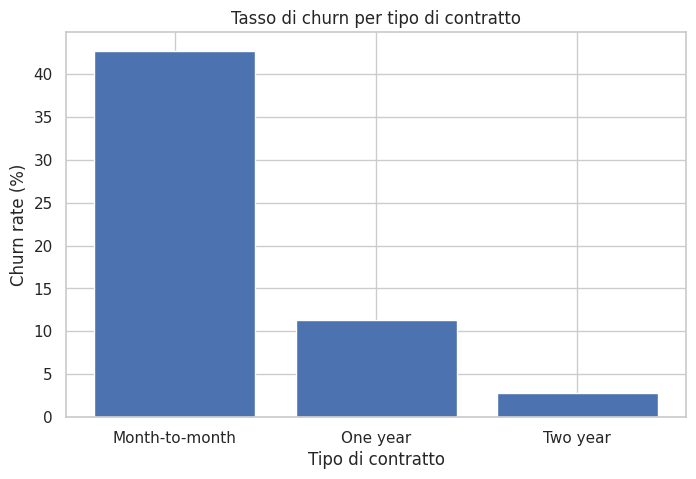

In [ ]:
#Contract e Churn
#Grafico: barplot del tasso di churn per tipo di contratto

contract_churn = churn_rate_table(df, "Contract")

print("Tasso di churn per tipo di contratto")
display(contract_churn)

plt.figure(figsize=(8, 5))
plt.bar(contract_churn["Contract"], contract_churn["Churn rate (%)"])
plt.title("Tasso di churn per tipo di contratto")
plt.xlabel("Tipo di contratto")
plt.ylabel("Churn rate (%)")
plt.show()

Il barplot confronta il tasso di churn tra tre gruppi di clienti: contratto mensile, annuale e biennale. Il gruppo `Month-to-month` presenta un tasso di churn nettamente più alto rispetto ai contratti di durata maggiore; questo suggerisce che la stabilità contrattuale sia associata a una minore probabilità di abbandono.

## Ipotesi 2 — I clienti con tenure più bassa sono più propensi al churn?

Statistiche descrittive di tenure per classe Churn


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,37.65,24.08,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.98,19.53,1.0,2.0,10.0,29.0,72.0


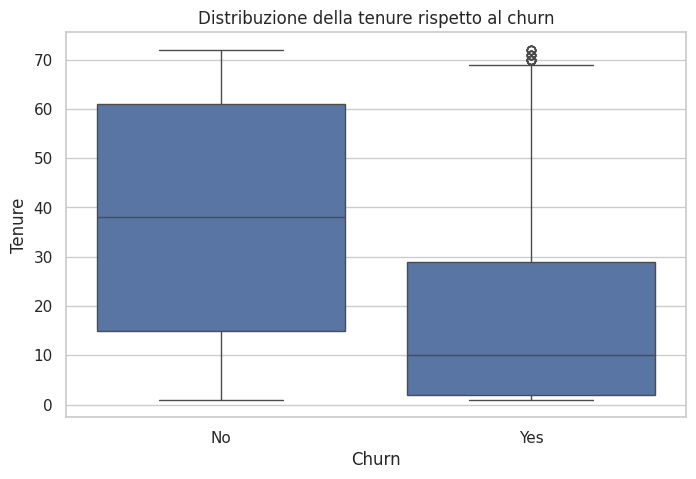

In [ ]:
#Tenure e Churn
#Grafico: boxplot della tenure rispetto al target

tenure_summary = df.groupby("Churn")["tenure"].describe().round(2)

print("Statistiche descrittive di tenure per classe Churn")
display(tenure_summary)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Distribuzione della tenure rispetto al churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()

Il boxplot mette a confronto la durata del rapporto con l'azienda tra clienti che abbandonano e clienti che rimangono. I clienti con `Churn = Yes` tendono ad avere valori di `tenure` più bassi; questo risultato è coerente con l'ipotesi secondo cui i clienti più recenti sono meno fidelizzati e quindi più propensi ad abbandonare il servizio.

## Ipotesi 3 — I clienti con spese mensili più alte presentano maggiore probabilità di churn?

Statistiche descrittive di MonthlyCharges per classe Churn


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.31,31.09,18.25,25.10,64.45,88.48,118.75
Yes,1869.0,74.44,24.67,18.85,56.15,79.65,94.20,118.35


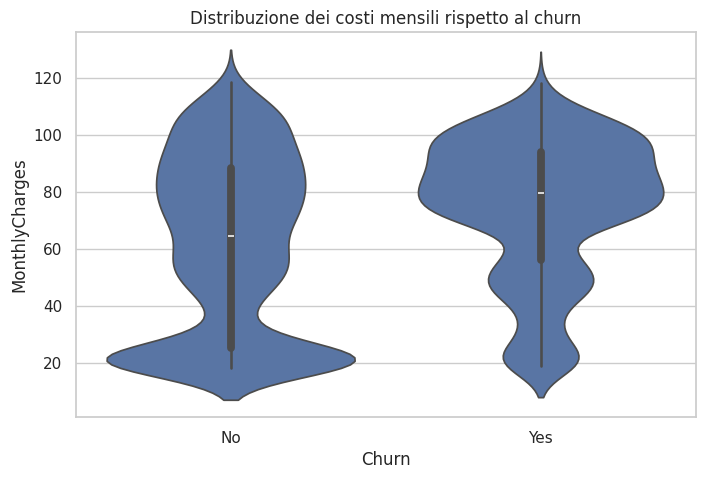

In [ ]:
#MonthlyCharges e Churn
#Grafico: violin plot dei costi mensili rispetto al target

monthly_summary = df.groupby("Churn")["MonthlyCharges"].describe().round(2)

print("Statistiche descrittive di MonthlyCharges per classe Churn")
display(monthly_summary)

plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Distribuzione dei costi mensili rispetto al churn")
plt.xlabel("Churn")
plt.ylabel("MonthlyCharges")
plt.show()

Il violin plot mostra non solo valori centrali e dispersione, ma anche la forma della distribuzione dei costi mensili. I clienti che abbandonano sembrano concentrarsi più spesso su valori medio-alti di `MonthlyCharges`. Questo suggerisce che il costo mensile del servizio possa essere uno dei fattori associati al churn.

## Ipotesi 4 — L'assenza di servizi di supporto è associata a un churn più elevato?

Tasso di churn per TechSupport


,TechSupport,Churn rate (%)
0,No,41.65
1,Yes,15.20
2,No internet service,7.43


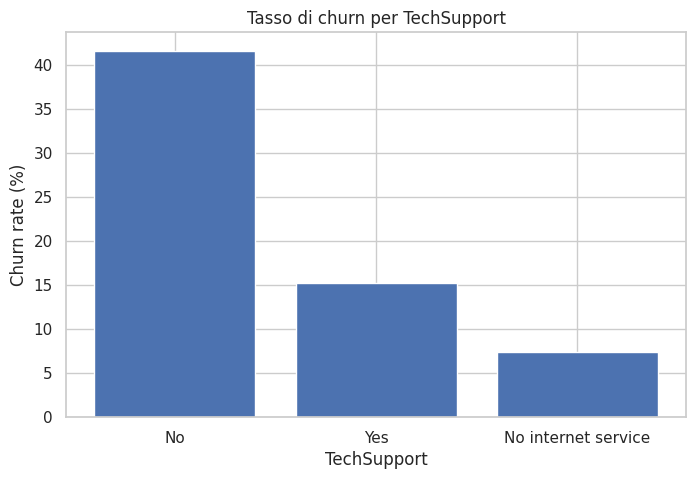

Tasso di churn per OnlineSecurity


,OnlineSecurity,Churn rate (%)
0,No,41.78
1,Yes,14.64
2,No internet service,7.43


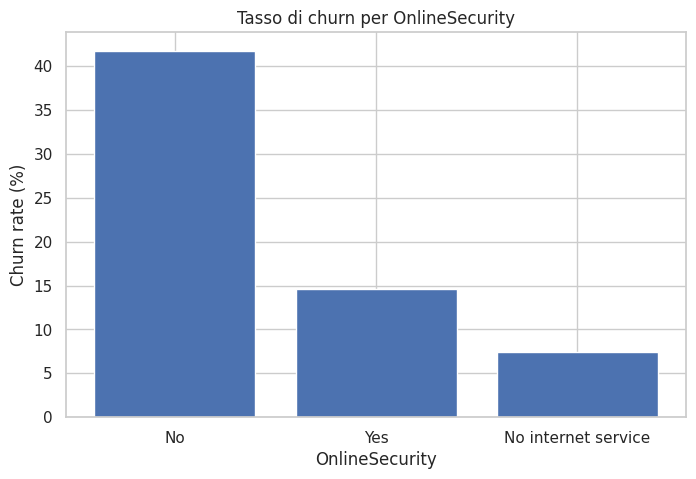

In [ ]:
#TechSupport, OnlineSecurity e Churn
#Grafici: barplot del tasso di churn per servizi di supporto

techsupport_churn = churn_rate_table(df, "TechSupport")
onlinesecurity_churn = churn_rate_table(df, "OnlineSecurity")

print("Tasso di churn per TechSupport")
display(techsupport_churn)

plt.figure(figsize=(8, 5))
plt.bar(techsupport_churn["TechSupport"], techsupport_churn["Churn rate (%)"])
plt.title("Tasso di churn per TechSupport")
plt.xlabel("TechSupport")
plt.ylabel("Churn rate (%)")
plt.show()

print("Tasso di churn per OnlineSecurity")
display(onlinesecurity_churn)

plt.figure(figsize=(8, 5))
plt.bar(onlinesecurity_churn["OnlineSecurity"], onlinesecurity_churn["Churn rate (%)"])
plt.title("Tasso di churn per OnlineSecurity")
plt.xlabel("OnlineSecurity")
plt.ylabel("Churn rate (%)")
plt.show()

I grafici mostrano che i clienti senza `TechSupport` e senza `OnlineSecurity` presentano un tasso di churn più elevato rispetto ai clienti che dispongono di questi servizi. Questo risultato suggerisce che l'assistenza tecnica e la sicurezza online possano contribuire alla permanenza del cliente, oppure che la loro assenza sia associata a profili di clienti più propensi ad abbandonare.


Abbiamo notato visivamente che sia l'assenza di `TechSupport` sia l'assenza di `OnlineSecurity` erano associate a un forte incremento del tasso di churn; ciò  ha sollevato un dubbio, ovvero se i due servizi fossero acquistati sempre in coppia dagli stessi utenti (rendendo una delle due feature ridondante), oppure se rappresentino comportamenti di acquisto indipendenti che riducono il churn in modi distinti. Per questo motivo, verifichiamo usando l'inidce di Pearson.


In [ ]:
#Verifica Ridondanza: TechSupport vs OnlineSecurity

#Tabella di contingenza (Crosstab) per vedere quanti clienti hanno le stesse combinazioni
tabella_incrociata = pd.crosstab(df['TechSupport'], df['OnlineSecurity'], margins=True)
print("--- Tabella di Contingenza (Conteggi Incrociati) ---")
display(tabella_incrociata)

#Codifichiamo le variabili in numeri per calcolare la correlazione lineare
#Escludiamo eventuali risposte come 'No internet service' mappandole a 0 insieme ai 'No'
mapping = {'Yes': 1, 'No': 0, 'No internet service': 0}

tech_numeric = df['TechSupport'].map(mapping)
security_numeric = df['OnlineSecurity'].map(mapping)

# Calcoliamo la correlazione di Pearson tra le due nuove serie numeriche
correlazione = tech_numeric.corr(security_numeric)
print(f"\nIndice di correlazione lineare di Pearson: {correlazione:.4f}")

--- Tabella di Contingenza (Conteggi Incrociati) ---


OnlineSecurity,No,No internet service,Yes,All
TechSupport,,,,
No,2553,0,919,3472
No internet service,0,1520,0,1520
Yes,944,0,1096,2040
All,3497,1520,2015,7032



Indice di correlazione lineare di Pearson: 0.3545


Abbiamo codificato numericamente le due feature e calcolato l'indice di correlazione lineare di Pearson, il quale ha restituito un valore pari a 0.3545; questo coefficiente evidenzia una correlazione positiva debole-moderata. Sebbene esista una leggera tendenza da parte dei clienti ad associare i due servizi di protezione, la stragrande maggioranza della clientela compie scelte d'acquisto separate. Possiamo dunque mantenere entrambe le varibaili nel dataset senza problemi nella fase di machine learning.

## Confronto aggiuntivo 1 — Contratto, tenure e churn

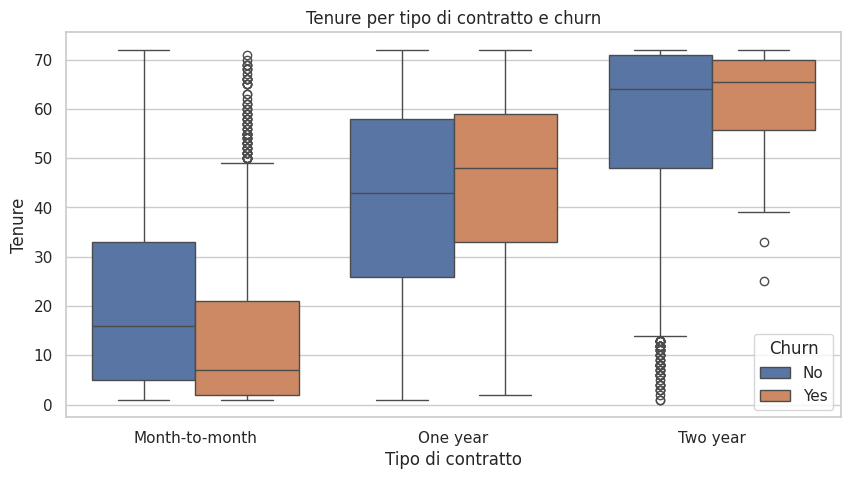

In [ ]:
# 6. CONFRONTO TRA CONTRACT, TENURE E CHURN
# Grafico: boxplot con hue sul target

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Contract", y="tenure", hue="Churn")
plt.title("Tenure per tipo di contratto e churn")
plt.xlabel("Tipo di contratto")
plt.ylabel("Tenure")
plt.show()

Questo grafico rappresenta un primo confronto multivariato: combina una variabile categorica (`Contract`), una variabile numerica (`tenure`) e il target (`Churn`). I clienti con contratto mensile tendono ad avere una tenure più bassa e una maggiore presenza di churn. Nei contratti annuali e biennali il churn appare meno frequente e associato a rapporti mediamente più lunghi.

## Confronto aggiuntivo 2 — InternetService, MonthlyCharges e churn

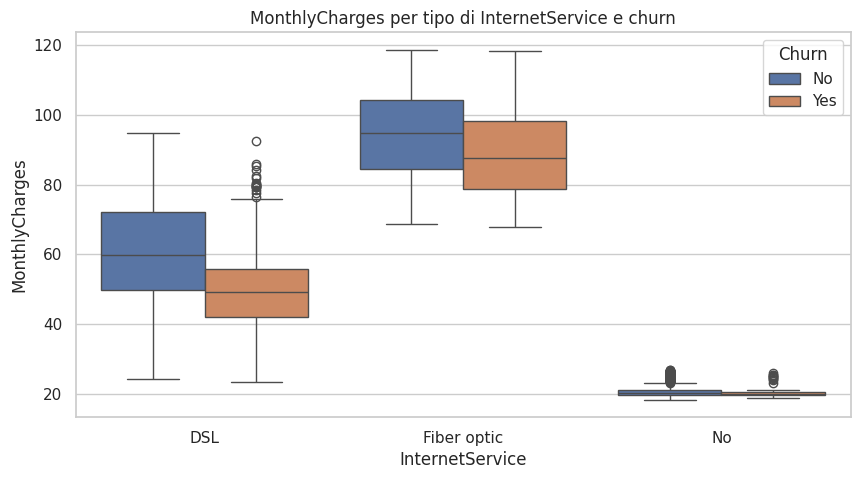

In [ ]:
# 7. CONFRONTO TRA INTERNETSERVICE, MONTHLYCHARGES E CHURN
# Grafico: boxplot con hue sul target

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="InternetService", y="MonthlyCharges", hue="Churn")
plt.title("MonthlyCharges per tipo di InternetService e churn")
plt.xlabel("InternetService")
plt.ylabel("MonthlyCharges")
plt.show()

Questo secondo confronto mette in relazione il tipo di servizio Internet, il costo mensile e il churn. I clienti con `Fiber optic` tendono ad avere costi mensili più elevati. Poiché questo gruppo mostra anche un tasso di churn elevato, è plausibile che il `Churn` dipenda da una combinazione di fattori: tipo di servizio, prezzo e percezione del valore ricevuto.

## Heatmap — Correlazioni tra variabili numeriche e churn

Matrice di correlazione


/tmp/ipykernel_6786/2176563401.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  corr_data["Churn_binary"] = df["Churn"].replace({


,tenure,MonthlyCharges,TotalCharges,Churn_binary
tenure,1.00,0.25,0.83,-0.35
MonthlyCharges,0.25,1.00,0.65,0.19
TotalCharges,0.83,0.65,1.00,-0.20
Churn_binary,-0.35,0.19,-0.20,1.00


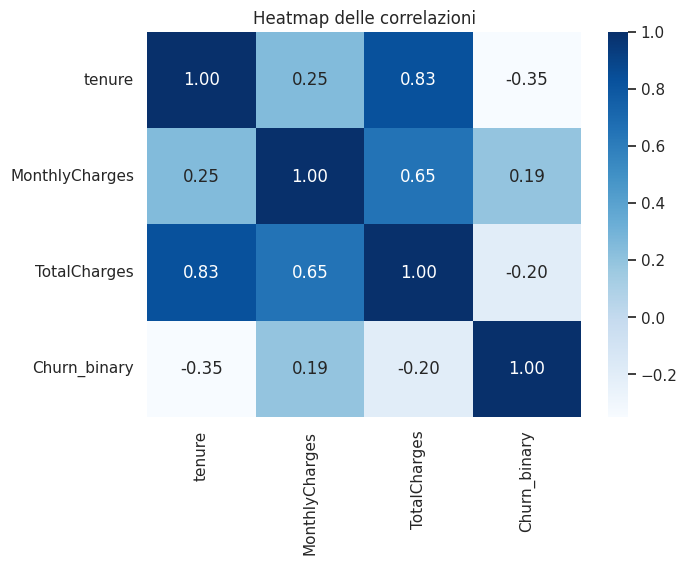

In [ ]:
# 8. HEATMAP DELLE CORRELAZIONI
# Grafico: heatmap su variabili numeriche e target binario

corr_data = df[["tenure", "MonthlyCharges", "TotalCharges"]].copy()

corr_data["Churn_binary"] = df["Churn"].replace({
    "No": 0,
    "Yes": 1
})

corr_matrix = corr_data.corr().round(2)

print("Matrice di correlazione")
display(corr_matrix)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Heatmap delle correlazioni")
plt.show()

L'analisi dei coefficienti di correlazione di Pearson rivela dinamiche fondamentali sul comportamento dei clienti rispetto alla variabile target Churn_numeric:

* `Tenure`  e `Churn` (correlazione negativa, $-0.35$): si tratta della relazione più evidente riscontrata con il target. Il segno negativo indica una proporzionalità inversa: al crescere dei mesi di fedeltà dell'utente (tenure), la propensione all'abbandono diminuisce sensibilmente. Questo conferma l'ipotesi che i clienti storici siano più stabili e fidelizzati.
* `MonthlyCharges`e `Churn` (correlazione positiva, $+0.19$): il segno positivo indica che tariffe mensili più elevate tendono ad associarsi a un tasso di churn maggiore. I costi ricorrenti alti agiscono come un fattore che induce l'utente a guardarsi intorno alla ricerca di concorrenti più economici.
* `TotalCharges` e `Churn` (debole correlazione negativa, $-0.20$): la spesa totale è trainata dalla permanenza dell'utente; pertanto, i clienti che hanno accumulato costi totali molto alti sono per definizione clienti storici, e quindi meno propensi a recedere nell'immediato.

Un'evidenza fondamentale che emerge dal grafico è la correlazione lineare molto alta tra `Tenure` e `TotalCharges` ($+0.83$). La relazione è logicamente ovvia, dato che più mesi un cliente rimane con l'azienda più fatture accumulerà nel tempo, facendo lievitare la spesa totale complessiva.
Questa sovrapposizione informativa sarà considerata nella fase di modellazione, soprattutto nell’interpretazione dei risultati. In particolare, sarà importante valutare se entrambe le variabili contribuiscono realmente alla capacità predittiva dei modelli oppure se una delle due risulta in parte ridondante.

## Sintesi finale della Fase 3

La Fase 3 ha permesso di analizzare le relazioni tra alcune feature rilevanti e il target `Churn`.

Le evidenze principali sono:

1. Il tipo di contratto appare fortemente associato al `Churn`: i clienti con contratto mensile abbandonano più frequentemente.
2. La `tenure` è più bassa tra i clienti che abbandonano, suggerendo una minore fidelizzazione dei clienti recenti.
3. I clienti con costi mensili più elevati mostrano una maggiore tendenza al `Churn`.
4. L'assenza di servizi come `TechSupport` e `OnlineSecurity` è associata a tassi di churn più elevati.
5. Alcune variabili sembrano agire congiuntamente: ad esempio `InternetService`, `MonthlyCharges` e `Churn` mostrano una relazione interessante.

Queste analisi non dimostrano rapporti causali, ma aiutano a formulare ipotesi utili per la successiva fase di modellazione.

# Fase 4 - Modellazione

In questa fase l'obiettivo è preparare il dataset per la classificazione e confrontare modelli diversi.

Requisiti della fase:

- conversione delle variabili categoriche in variabili numeriche;
- train/test split;
- confronto di almeno 3 modelli diversi;
- uso di almeno un modello lineare e almeno un modello non lineare.

I modelli scelti sono:

1. **Regressione Logistica**: modello lineare;
2. **k-Nearest Neighbors (k-NN)**: modello non lineare;
3. **Random Forest**: modello non lineare basato su alberi decisionali.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Import delle librerie

Importiamo le librerie necessarie per gestire i dati, preparare il dataset, costruire i modelli e calcolare una prima metrica di confronto.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)
np.random.seed(42)

In questa cella vengono importate le librerie principali.  
`pandas` e `numpy` servono per la gestione dei dati, mentre `scikit-learn` viene usato per preparare il dataset e addestrare i modelli di classificazione.

## 2. Caricamento del dataset pulito

Carichiamo il dataset prodotto alla fine della Fase 2. In questo modo la modellazione parte da dati già controllati rispetto a missing values, duplicati e problemi nella colonna `TotalCharges`.

In [ ]:
df = pd.read_csv("/content/sample_data/Customer_Churn_clean.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Separazione tra feature e target

Prima di costruire i modelli separiamo:

- `X`: variabili esplicative, cioè le feature usate per prevedere il churn;
- `y`: variabile target, cioè `Churn`.

Inoltre eliminiamo `customerID`, perché è solo un identificativo e non contiene informazioni utili per la classificazione.

In [ ]:
y = df["Churn"].map({"No": 0, "Yes": 1})

X = df.drop(columns=["Churn", "customerID"])

print("Dimensioni X:", X.shape)
print("Dimensioni y:", y.shape)

X.head()

Dimensioni X: (7032, 19)
Dimensioni y: (7032,)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


La variabile `Churn` viene trasformata in formato numerico: `0` indica i clienti che non abbandonano, mentre `1` indica i clienti che abbandonano.  
La colonna `customerID` viene rimossa perché rappresenta un codice identificativo univoco e potrebbe introdurre rumore nel modello.

## 4. Conversione delle variabili categoriche in numeriche

Per usare i modelli di classificazione è necessario convertire le variabili testuali in variabili numeriche.

Usiamo un comando semplice e riproducibile: `pd.get_dummies()`.  
Questo metodo crea automaticamente nuove colonne binarie per le categorie delle variabili qualitative.

In [ ]:
X = pd.get_dummies(X, drop_first=True, dtype=int)

X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


La funzione `pd.get_dummies()` trasforma le variabili categoriche in colonne numeriche composte da valori 0/1.  
Il parametro `dtype=int` forza la rappresentazione dei valori come interi (0/1) invece che come booleani (True/False), rendendo l'output più leggibile e uniforme.
La colonna `SeniorCitizen` non viene modificata perché era già in formato numerico.
L'opzione `drop_first=True` evita di creare colonne ridondanti, riducendo il rischio di multicollinearità nei modelli lineari.

## 5. Controllo finale del dataset per la classificazione

Verifichiamo che tutte le variabili siano numeriche e che non siano rimaste colonne di tipo `object`.

In [ ]:
print("Dimensioni finali di X dopo encoding:", X.shape)
print("Tipi di dato presenti in X:")
print(X.dtypes.value_counts())

print("Numero di colonne object rimaste:", len(X.select_dtypes(include="object").columns))

Dimensioni finali di X dopo encoding: (7032, 30)
Tipi di dato presenti in X:
int64      28
float64     2
Name: count, dtype: int64
Numero di colonne object rimaste: 0


Dopo la conversione, il dataset è pronto per la classificazione.  
Il controllo sui tipi di dato permette di verificare che le variabili categoriche siano state effettivamente trasformate in variabili numeriche.

In [ ]:
X = pd.get_dummies(X, drop_first=True, dtype=int)
# Creazione e salvataggio del dataset codificato completo
df_encoded = X. copy()
df_encoded ["Churn"] = y
encoded_path = "/content/sample_data/Customer_Churn_encoded.csv"
df_encoded.to_csv (encoded_path, index=False)
print("Dataset codificato salvato in:", encoded_path)
print ("Dimensioni dataset codificato:", df_encoded.shape)
display(df_encoded.head())

Dataset codificato salvato in: /content/sample_data/Customer_Churn_encoded.csv
Dimensioni dataset codificato: (7032, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1


In questa fase abbiamo trasformato le variabili categoriali in numeri attraverso il porcesso di codifica, rendendo il dataset pronto per i modelli di Machine Learning; infine, abbiamo ricomposto il dataset indserendo la colonna target Churn e abbiamo salvato il file finale in formato CSV all'interno della cartella sample_data.

## 6. Train/test split

Dividiamo il dataset in:

- training set: usato per addestrare i modelli;
- test set: usato per valutare i modelli su dati non visti.

Usiamo `stratify=y` perché nella Fase 2 abbiamo osservato uno sbilanciamento tra le classi di `Churn`. In questo modo la proporzione tra clienti churner e non churner rimane simile sia nel training set sia nel test set.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("Distribuzione target nel training set:")
print(y_train.value_counts(normalize=True).round(3))

print("Distribuzione target nel test set:")
print(y_test.value_counts(normalize=True).round(3))

X_train: (5625, 30)
X_test: (1407, 30)
y_train: (5625,)
y_test: (1407,)
Distribuzione target nel training set:
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64
Distribuzione target nel test set:
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64


Il dataset viene diviso assegnando l'80% delle osservazioni al training set e il 20% al test set.  
La stratificazione è importante perché mantiene stabile la distribuzione della variabile target, evitando che una delle due classi sia rappresentata in modo troppo diverso tra training e test.

In [ ]:
#Ricomponiamo i dataset unendo X (feature) e Y (target)
df_train= X_train.copy()
df_train["Churn"]= y_train

df_test= X_test.copy()
df_test["Churn"]= y_test

#Salviamo i file nella cartella sample_data
train_path="sample_data/Customer_Churn_train_set.csv"
test_path="sample_data/Customer_Churn_test_set.csv"
df_train.to_csv(train_path, index=False)
df_test.to_csv(test_path, index=False)

Il codice ha completato la separazione dei dati in Training Set (80%) e Test Set (20%), assicurando una distribuzione identica della variabile Churn in entrambi i blocchi grazie alla stratificazione. Le feature e il target sono stati poi ricongiunti per generare e scaricare automaticamente i due file CSV indipendenti, pronti per le fasi successive di modellazione.

## 7. Standardizzazione delle feature

Alcuni modelli, come k-NN e Regressione Logistica, sono sensibili alla scala delle variabili.  
Per questo motivo standardizziamo le feature usando `StandardScaler`.

Lo scaler viene calcolato solo sul training set e poi applicato anche al test set. Questo evita data leakage.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardizzazione completata.")

Standardizzazione completata.


La standardizzazione porta le variabili su una scala comparabile.  
È importante usare `fit_transform()` solo sul training set e `transform()` sul test set, perché il test set deve simulare dati nuovi e non deve influenzare la preparazione del modello.

## 8. Definizione dei modelli

Definiamo tre modelli diversi:

- Regressione Logistica: modello lineare;
- k-NN: modello non lineare basato sulla vicinanza tra osservazioni;
- Random Forest: modello non lineare basato su molti alberi decisionali.

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "k-NN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

models

{'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
 'k-NN': KNeighborsClassifier(),
 'Random Forest': RandomForestClassifier(random_state=42)}

## 9. Addestramento dei modelli

Addestriamo tutti i modelli sul training set standardizzato e salviamo le predizioni sul test set.
Ogni modello viene addestrato sugli stessi dati di training e poi usato per prevedere il `Churn` nel test set.  

In [ ]:
trained_models = {}
predictions = {}

for model_name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    trained_models[model_name] = model
    predictions[model_name] = y_pred

    print(model_name, "addestrato correttamente.")

Logistic Regression addestrato correttamente.
k-NN addestrato correttamente.
Random Forest addestrato correttamente.


## 10. Primo confronto tramite accuracy

Per avere un primo confronto tra i modelli calcoliamo l'accuracy sul test set.  

In [ ]:
accuracy_results = []

for model_name, y_pred in predictions.items():
    acc = accuracy_score(y_test, y_pred)

    accuracy_results.append({
        "Modello": model_name,
        "Accuracy": round(acc, 4)
    })

accuracy_table = pd.DataFrame(accuracy_results).sort_values(by="Accuracy", ascending=False)

accuracy_table

,Modello,Accuracy
0,Logistic Regression,0.8038
2,Random Forest,0.7882
1,k-NN,0.7534


La tabella mostra una prima misura di performance dei modelli.  
L'accuracy è utile come confronto iniziale, ma non basta per valutare pienamente i risultati, perché nella Fase 2 abbiamo osservato che la variabile target è sbilanciata.  
Per questo nella Fase 5 sarà necessario analizzare anche precision, recall, F1-score e confusion matrix.

## 11. Visualizzazione del confronto tra modelli

Rappresentiamo graficamente l'accuracy ottenuta dai tre modelli.

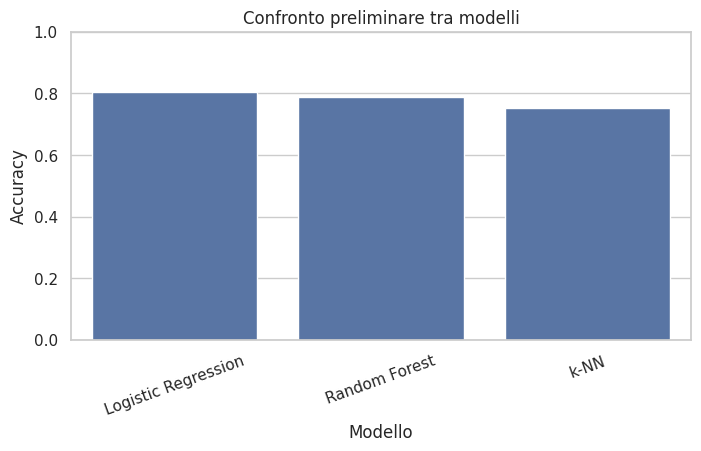

In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(data=accuracy_table, x="Modello", y="Accuracy")
plt.title("Confronto preliminare tra modelli")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

 Questa analisi è preliminare: il confronto definitivo verrà svolto nella Fase 5 usando più metriche, in modo da valutare anche il comportamento dei modelli sulla classe minoritaria `Churn = Yes`.

## 12. Sintesi della Fase 4

In questa fase abbiamo:

1. separato feature e target;
2. convertito le variabili categoriche in numeriche con `pd.get_dummies()`;
3. diviso il dataset in training set e test set;
4. standardizzato le feature;
5. addestrato tre modelli diversi:
   - Regressione Logistica;
   - k-NN;
   - Random Forest;
6. prodotto un primo confronto tramite accuracy.


# Fase 5 - Valutazione e interpretazione dei risultati

In questa fase valutiamo criticamente i tre modelli addestrati nella Fase 4:

1. **Regressione Logistica**;
2. **k-Nearest Neighbors (k-NN)**;
3. **Random Forest**.

Per ogni modello calcoliamo le metriche richieste dal progetto:

- accuracy;
- confusion matrix;
- precision;
- recall;
- F1-score.

Poiché nella Fase 2 è emerso uno sbilanciamento della variabile target `Churn`, l'accuracy non viene considerata da sola. Precision, recall e F1-score sono fondamentali per valutare meglio il comportamento dei modelli sulla classe minoritaria, cioè i clienti che abbandonano il servizio.

**Nota sulla ripetizione della preparazione dati**

La Fase 5 riprende la stessa preparazione dei dati della Fase 4 per valutare in modo completo i modelli. Questa scelta rende il notebook più leggibile e riproducibile, perché la valutazione parte esplicitamente dallo stesso dataset, dalla stessa conversione delle variabili categoriche, dallo stesso train/test split e dalla stessa standardizzazione usati nella fase di modellazione.

## 1. Import delle librerie

Importiamo le librerie per gestire i dati, ricostruire la preparazione del dataset, addestrare i modelli e calcolare le metriche di valutazione.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)
np.random.seed(42)

Importiamo le librerie già utilizzate nella Fase 4 e aggiunge le metriche necessarie per la Fase 5.  
Le metriche principali sono `accuracy_score`, `precision_score`, `recall_score`, `f1_score` e `confusion_matrix`.

## 2. Caricamento del dataset pulito

Carichiamo il dataset pulito prodotto nella Fase 2. In questo modo la valutazione parte dagli stessi dati usati nella fase di modellazione.

In [ ]:
df = pd.read_csv("/content/sample_data/Customer_Churn_clean.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


La colonna `Churn` è la variabile target: indica se il cliente ha abbandonato o meno il servizio.

## 3. Preparazione di feature e target

Ricostruiamo la separazione tra:

- `X`: variabili esplicative;
- `y`: variabile target.

La colonna `customerID` viene rimossa perché è solo un identificativo del cliente.

In [ ]:
y = df["Churn"].map({"No": 0, "Yes": 1})

X = df.drop(columns=["Churn", "customerID"])

print("Dimensioni X:", X.shape)
print("Dimensioni y:", y.shape)

X.head()

Dimensioni X: (7032, 19)
Dimensioni y: (7032,)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


La variabile target viene trasformata in formato numerico: `0` corrisponde a `No`, mentre `1` corrisponde a `Yes`.  

## 4. Conversione delle variabili categoriche

Convertiamo le variabili categoriche in variabili numeriche usando `pd.get_dummies()`, come nella Fase 4.

In [ ]:
X = pd.get_dummies(X, drop_first=True, dtype=int)

print("Dimensioni X dopo encoding:", X.shape)
print("Numero colonne object rimaste:", len(X.select_dtypes(include="object").columns))

X.head()

Dimensioni X dopo encoding: (7032, 30)
Numero colonne object rimaste: 0


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0



`pd.get_dummies()` trasforma le categorie testuali in colonne binarie 0/1.  
Il parametro `dtype=int` forza la rappresentazione dei valori come interi (0/1) invece che come booleani (True/False), rendendo l'output più leggibile e uniforme. La colonna SeniorCitizen non viene modificata perché era già in formato numerico.
L'opzione `drop_first=True` evita colonne ridondanti e rende il dataset adatto ai modelli di classificazione.

**SALVARE IL FILE RICODIFICATO E CARICARLO SU GITHUB NELLA CARTELLA DATA INSIEME A QUELLO ORIGINALE!!!!**

## 5. Train/test split

Dividiamo il dataset in training set e test set. Usiamo `stratify=y` per mantenere proporzioni simili delle classi `Churn = No` e `Churn = Yes` nei due insiemi.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("Distribuzione target nel training set:")
print(y_train.value_counts(normalize=True).round(3))

print("Distribuzione target nel test set:")
print(y_test.value_counts(normalize=True).round(3))

X_train: (5625, 30)
X_test: (1407, 30)
y_train: (5625,)
y_test: (1407,)
Distribuzione target nel training set:
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64
Distribuzione target nel test set:
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64



Il dataset viene diviso in 80% training set e 20% test set.  
La stratificazione è importante perché il target è sbilanciato: mantenere la stessa distribuzione delle classi rende la valutazione più affidabile.

## 6. Standardizzazione delle variabili

Applichiamo la standardizzazione alle feature. Questo passaggio è particolarmente utile per k-NN e Regressione Logistica.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardizzazione completata.")

Standardizzazione completata.


Lo scaler viene calcolato solo sul training set con `fit_transform()` e poi applicato al test set con `transform()`.  
Questo evita data leakage, perché il test set non deve influenzare la preparazione dei dati.

## 7. Definizione e addestramento dei modelli

Ricostruiamo i tre modelli della Fase 4 e li addestriamo sul training set.

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "k-NN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

trained_models = {}
predictions = {}

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    trained_models[model_name] = model
    predictions[model_name] = y_pred

    print(model_name, "addestrato e valutato sul test set.")

Logistic Regression addestrato e valutato sul test set.
k-NN addestrato e valutato sul test set.
Random Forest addestrato e valutato sul test set.


Per rendere il confronto più corretto, tutti i modelli vengono addestrati sugli stessi dati di training e valutati sullo stesso test set.  

## 8. Calcolo delle metriche richieste

Per ogni modello calcoliamo:

- accuracy;
- precision;
- recall;
- F1-score.

Le metriche sono calcolate considerando `Churn = 1 (YES)` come classe positiva, cioè la classe più importante per il problema.

In [ ]:
metrics_results = []

for model_name, y_pred in predictions.items():

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    metrics_results.append({
        "Modello": model_name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-score": round(f1, 4)
    })

metrics_table = pd.DataFrame(metrics_results)
metrics_table = metrics_table.sort_values(by="F1-score", ascending=False)

metrics_table

,Modello,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.8038,0.6476,0.5749,0.6091
2,Random Forest,0.7882,0.6234,0.5134,0.5630
1,k-NN,0.7534,0.5362,0.5348,0.5355


Dalla tabella emerge che la Regressione Logistica ottiene i valori
più alti su tutte le metriche.
Il Random Forest si colloca al secondo posto, mentre k-NN risulta il meno
performante. Nessun modello raggiunge
recall elevata sulla classe Yes, il che riflette la difficoltà
intrinseca del problema con dati sbilanciati.

## 9. Confusion matrix per ogni modello

La confusion matrix mostra il numero di:

- veri negativi: clienti correttamente classificati come non churner;
- falsi positivi: clienti previsti come churner ma che non abbandonano;
- falsi negativi: clienti previsti come non churner ma che abbandonano;
- veri positivi: clienti correttamente classificati come churner.

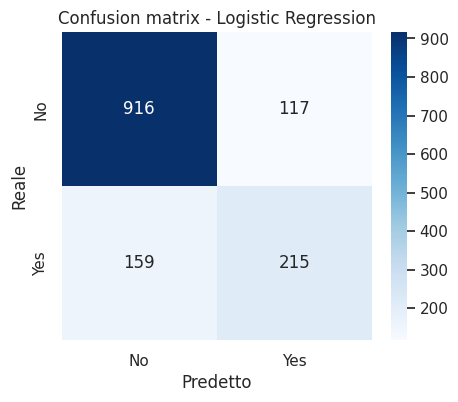

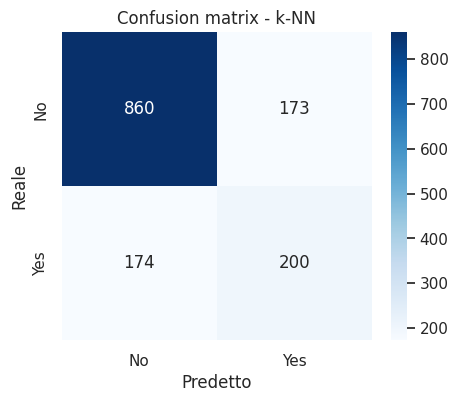

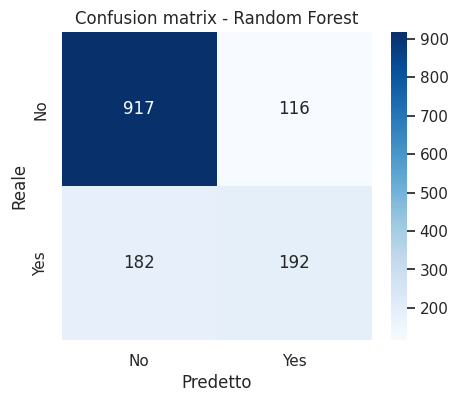

In [ ]:
confusion_matrices = {}

for model_name, y_pred in predictions.items():

    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices[model_name] = cm

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No", "Yes"],
        yticklabels=["No", "Yes"]
    )
    plt.title(f"Confusion matrix - {model_name}")
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    plt.show()

Le confusion matrix permettono di capire il tipo di errore commesso dai modelli.  
Nel problema del `churn` sono particolarmente importanti i **falsi negativi**, cioè clienti che il modello prevede come non a rischio ma che in realtà abbandonano il servizio. Questo tipo di errore è rilevante perché impedisce all’azienda di intervenire in anticipo sui clienti potenzialmente a rischio.

Dal confronto tra le matrici di confusione, la Regressione Logistica sembra offrire il risultato più equilibrato: mantiene una buona capacità di classificare correttamente i clienti che rimangono e, allo stesso tempo, riconosce meglio rispetto agli altri modelli i casi di abbandono.

## 10. Tabella dettagliata delle confusion matrix


In [ ]:
cm_results = []

for model_name, cm in confusion_matrices.items():
    tn, fp, fn, tp = cm.ravel()

    cm_results.append({
        "Modello": model_name,
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "True Positive": tp
    })

cm_table = pd.DataFrame(cm_results)
cm_table

,Modello,True Negative,False Positive,False Negative,True Positive
0,Logistic Regression,916,117,159,215
1,k-NN,860,173,174,200
2,Random Forest,917,116,182,192




Questa tabella rende più semplice confrontare gli errori dei modelli.  
Un modello utile per il `churn` dovrebbe cercare di ridurre i falsi negativi, perché non individuare un cliente realmente a rischio può essere un problema operativo per l'azienda.

## 11. Classification report per ogni modello

Il classification report mostra precision, recall e F1-score separatamente per entrambe le classi: `No` e `Yes`.

In [ ]:
for model_name, y_pred in predictions.items():
    print("="*70)
    print(model_name)
    print("="*70)
    print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))

Logistic Regression
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1033
         Yes       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

k-NN
              precision    recall  f1-score   support

          No       0.83      0.83      0.83      1033
         Yes       0.54      0.53      0.54       374

    accuracy                           0.75      1407
   macro avg       0.68      0.68      0.68      1407
weighted avg       0.75      0.75      0.75      1407

Random Forest
              precision    recall  f1-score   support

          No       0.83      0.89      0.86      1033
         Yes       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79  

Il classification report mostra le metriche separatamente per
classe No e Yes. Si nota che tutti i modelli performano meglio
sulla classe maggioritaria (No): questo è atteso con dati
sbilanciati, dove la classe No rappresenta circa il 73% dei casi.
La classe Yes è quella più critica per il business,
ma anche quella su cui tutti i modelli faticano di più.

## 12. Confronto grafico delle metriche

Visualizziamo le metriche principali per confrontare più chiaramente i modelli.

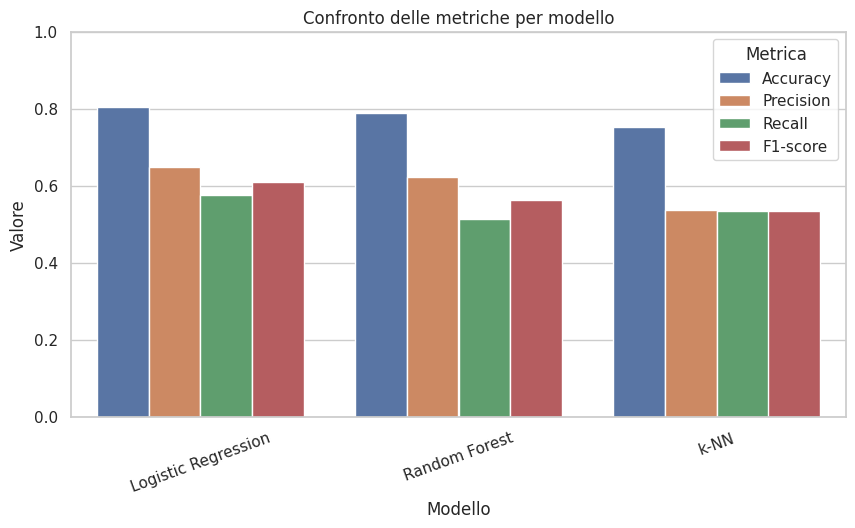

In [ ]:
metrics_long = metrics_table.melt(
    id_vars="Modello",
    value_vars=["Accuracy", "Precision", "Recall", "F1-score"],
    var_name="Metrica",
    value_name="Valore"
)

plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_long, x="Modello", y="Valore", hue="Metrica")
plt.title("Confronto delle metriche per modello")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Metrica")
plt.show()

Il grafico confronta le performance dei modelli su più metriche.  
Questo è utile perché un modello con accuracy elevata non è necessariamente il migliore se ha una recall bassa sulla classe `Churn = Yes`.

## 13. Interpretazione critica dei risultati

Riassumiamo i risultati principali dei tre modelli.

In [ ]:
best_accuracy_model = metrics_table.sort_values(by="Accuracy", ascending=False).iloc[0]
best_f1_model = metrics_table.sort_values(by="F1-score", ascending=False).iloc[0]
best_recall_model = metrics_table.sort_values(by="Recall", ascending=False).iloc[0]

print("Miglior modello per accuracy:")
print(best_accuracy_model)

print("Miglior modello per F1-score:")
print(best_f1_model)

print("Miglior modello per recall:")
print(best_recall_model)

Miglior modello per accuracy:
Modello      Logistic Regression
Accuracy                  0.8038
Precision                 0.6476
Recall                    0.5749
F1-score                  0.6091
Name: 0, dtype: object
Miglior modello per F1-score:
Modello      Logistic Regression
Accuracy                  0.8038
Precision                 0.6476
Recall                    0.5749
F1-score                  0.6091
Name: 0, dtype: object
Miglior modello per recall:
Modello      Logistic Regression
Accuracy                  0.8038
Precision                 0.6476
Recall                    0.5749
F1-score                  0.6091
Name: 0, dtype: object


In un problema di churn, la scelta del modello migliore non può basarsi
solo sull'accuracy. Con un dataset sbilanciato come il nostro, un modello che predicesse sempre "No" raggiungerebbe già
un'accuracy del 73% senza individuare nessun cliente a rischio.

Per questo motivo, la metrica più rilevante nel nostro contesto è la
**recall sulla classe Yes** : indica quanti clienti
realmente a rischio il modello riesce a identificare correttamente.
Un falso negativo — cioè un cliente churner classificato come "No" —
rappresenta un cliente perso che l'azienda non ha avuto la possibilità
di trattenere.

In un problema di `churn`, la scelta del modello migliore non può basarsi solo sull’accuracy dal momento che il dataset è sbilanciato.

Per questo motivo, nel nostro contesto è particolarmente importante osservare la recall della classe Yes, che indica quanti clienti che effettivamente abbandonano il servizio vengono identificati correttamente dal modello. Un falso negativo, cioè un cliente classificato come "No" ma che in realtà abbandona, rappresenta un caso critico: l’azienda non avrebbe la possibilità di intervenire in anticipo per provare a trattenerlo.

# 14. Approfondimento - Feature Importance nel Random Forest

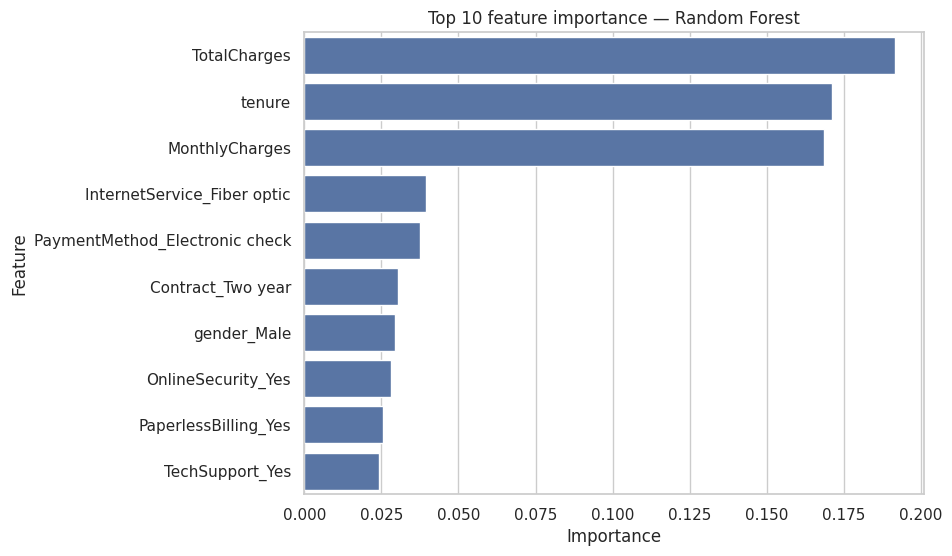

In [ ]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": trained_models["Random Forest"].feature_importances_
})
importance = importance.sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(
    data=importance.head(10),
    x="importance",
    y="feature"
)
plt.title("Top 10 feature importance — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()



La feature importance del Random Forest indica il contributo
relativo di ciascuna variabile alle decisioni del modello.
I valori sono normalizzati: la loro somma è circa 1, quindi
una feature con importanza 0.30 ha contribuito al 30% delle
decisioni complessive della foresta.

Dal grafico emergono alcune osservazioni interessanti:

- **tenure** e **TotalCharges** risultano tra le variabili più
  importanti, confermando quanto già osservato nella Fase 2:
  i clienti nuovi (tenure bassa) e con spese elevate tendono
  ad abbandonare di più. Questo è coerente anche con la
  correlazione negativa tra tenure e Churn (-0.35) vista
  nella heatmap.

- **MonthlyCharges** appare anch'essa tra le feature rilevanti,
  suggerendo che il costo mensile del servizio influisce
  sulla decisione di abbandonare.

- Le variabili relative ai servizi aggiuntivi (es.
  OnlineSecurity, TechSupport) hanno importanza più bassa,
  il che suggerisce che il comportamento di churn è guidato
  principalmente da fattori economici e di durata del
  contratto piuttosto che dai servizi specifici sottoscritti.

**Attenzione**:
feature importance NON implica causalità.

# 15. Approfondimento - Coefficienti Regressione Logistica

/tmp/ipykernel_6786/430363048.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_coef, x='Coefficiente', y='Feature',


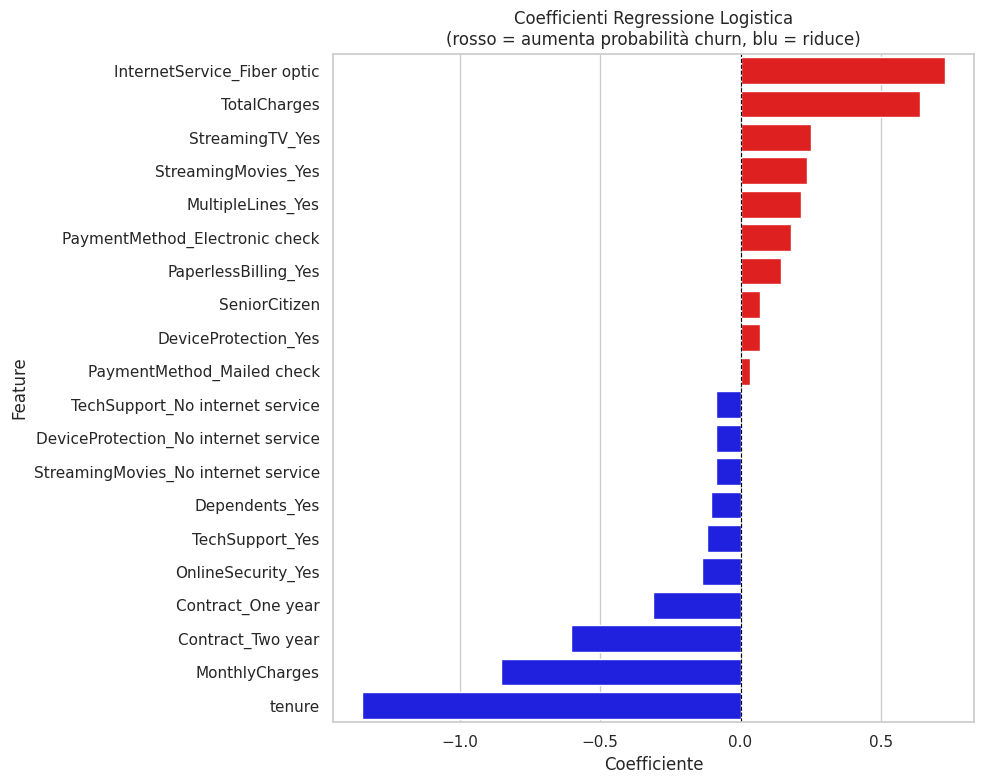

In [ ]:
# Recuperiamo i nomi delle feature dopo get_dummies
feature_names = X_train.columns.tolist()

# Recuperiamo i coefficienti dalla Regressione Logistica
coefficients = trained_models["Logistic Regression"].coef_[0]

# Creiamo un dataframe ordinato per valore assoluto
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficiente': coefficients
}).sort_values(by='Coefficiente', ascending=False)

# Mostriamo i top 10 positivi e top 10 negativi
top_pos = coef_df.head(10)
top_neg = coef_df.tail(10)
top_coef = pd.concat([top_pos, top_neg])

plt.figure(figsize=(10, 8))
sns.barplot(data=top_coef, x='Coefficiente', y='Feature',
            palette=['red' if c > 0 else 'blue' for c in top_coef['Coefficiente']])
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Coefficienti Regressione Logistica\n(rosso = aumenta probabilità churn, blu = riduce)')
plt.tight_layout()
plt.show()



I coefficienti indicano come ciascuna variabile influenza la
probabilità di churn: barre rosse (coefficiente positivo)
aumentano il rischio di abbandono, barre blu (coefficiente
negativo) lo riducono.

**Fattori che aumentano il rischio di churn:**
Il coefficiente più alto è **InternetService_Fiber optic**:
i clienti con fibra ottica abbandonano di più, probabilmente
perché è il servizio più costoso e competitivo. Anche
**StreamingTV_Yes**, **StreamingMovies_Yes** e
**PaymentMethod_Electronic check** contribuiscono positivamente
al churn, identificando un profilo di cliente digitale e
attento alle offerte di mercato.

**TotalCharges** mostra un coefficiente positivo apparentemente
controintuitivo: chi ha speso di più non dovrebbe essere meno
fedele? Questo risultato è probabilmente un effetto della
multicollinearità con tenure (correlazione 0.83): il modello
fatica a separare i due effetti opposti delle due variabili,
rendendo questo coefficiente meno affidabile.

**Fattori che riducono il rischio di churn:**
**Contract_One year** è il fattore protettivo più forte:
i clienti con contratto annuale sono significativamente
più fedeli. Anche **OnlineSecurity_Yes** e **TechSupport_Yes**
riducono il churn, suggerendo che i clienti con servizi
aggiuntivi percepiscono maggior valore nell'abbonamento
e sono meno propensi ad abbandonare.

Questi risultati sono coerenti con quanto osservato
nella Fase 2 e motivano ulteriormente l'esperimento
sulla multicollinearità nella sezione successiva.

# 16. Esperimento - Multicollinearità Regressione Logistica

In [ ]:
# Proviamo a rimuovere TotalCharges per ridurre la multicollinearità
X_no_tc = X.drop(columns=['TotalCharges'])

# Encoding e split
X_no_tc_encoded = pd.get_dummies(X_no_tc, drop_first=True, dtype=int)

X_train_no_tc, X_test_no_tc, y_train_no_tc, y_test_no_tc = train_test_split(
    X_no_tc_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler_no_tc = StandardScaler()
X_train_no_tc_scaled = scaler_no_tc.fit_transform(X_train_no_tc)
X_test_no_tc_scaled = scaler_no_tc.transform(X_test_no_tc)

# Regressione logistica senza TotalCharges
lr_no_tc = LogisticRegression(max_iter=1000, random_state=42)
lr_no_tc.fit(X_train_no_tc_scaled, y_train_no_tc)
y_pred_no_tc = lr_no_tc.predict(X_test_no_tc_scaled)

# Confronto metriche
print("=== Regressione Logistica CON TotalCharges ===")
print(f"Accuracy:  {accuracy_score(y_test, predictions['Logistic Regression']):.4f}")
print(f"Precision: {precision_score(y_test, predictions['Logistic Regression'], pos_label=1):.4f}")
print(f"Recall:    {recall_score(y_test, predictions['Logistic Regression'], pos_label=1):.4f}")
print(f"F1-score:  {f1_score(y_test, predictions['Logistic Regression'], pos_label=1):.4f}")

print("\n=== Regressione Logistica SENZA TotalCharges ===")
print(f"Accuracy:  {accuracy_score(y_test_no_tc, y_pred_no_tc):.4f}")
print(f"Precision: {precision_score(y_test_no_tc, y_pred_no_tc, pos_label=1):.4f}")
print(f"Recall:    {recall_score(y_test_no_tc, y_pred_no_tc, pos_label=1):.4f}")
print(f"F1-score:  {f1_score(y_test_no_tc, y_pred_no_tc, pos_label=1):.4f}")

=== Regressione Logistica CON TotalCharges ===
Accuracy:  0.8038
Precision: 0.6476
Recall:    0.5749
F1-score:  0.6091

=== Regressione Logistica SENZA TotalCharges ===
Accuracy:  0.8038
Precision: 0.6485
Recall:    0.5722
F1-score:  0.6080



Abbiamo testato empiricamente l'impatto della multicollinearità
tra tenure e TotalCharges (correlazione 0.83) riaddestrando
la Regressione Logistica dopo aver rimosso TotalCharges dal dataset.

| Metrica   | Con TotalCharges | Senza TotalCharges |
|-----------|------------------|--------------------|
| Accuracy  | 0.8038           | 0.8038             |
| Precision | 0.6476           | 0.6485             |
| Recall    | 0.5749           | 0.5722             |
| F1-score  | 0.6091           | 0.6080             |

I risultati mostrano differenze trascurabili tra i due modelli:
accuracy identica (0.80), precision e F1-score praticamente
invariate, recall con una variazione di soli 0.003 punti.

Questo risultato ha due implicazioni importanti:

**1. La multicollinearità non ha impattato le performance predittive.**
Questo conferma che la multicollinearità è
principalmente un problema di interpretabilità dei coefficienti,
non necessariamente di performance predittiva.

**2. TotalCharges è una variabile ridondante rispetto a tenure.**
Poiché la sua rimozione non cambia i risultati, possiamo
concludere che l'informazione contenuta in TotalCharges è
già in larga parte catturata da tenure e MonthlyCharges
combinati. Questo è coerente con la natura stessa della
variabile: TotalCharges ≈ tenure × MonthlyCharges.

In conclusione, per questo dataset la scelta di mantenere
o rimuovere TotalCharges non influenza le capacità predittive
del modello, ma la sua rimozione renderebbe i coefficienti
della regressione logistica più stabili e interpretabili.

# 17 - Riflessioni critiche sui modelli



### Regressione Logistica
**Punti di forza**: è il modello più performante tra i tre
(accuracy 0.80, F1 0.61) e il più interpretabile grazie ai
coefficienti, che permettono di capire quali variabili
influenzano la probabilità di churn e in che direzione.

**Limiti**: assume una relazione lineare tra le feature e
il target, il che potrebbe non catturare pattern più complessi
nei dati. La recall di 0.57 indica che quasi la metà dei
clienti churner reali non viene identificata.

**Tipo di errori**: produce più falsi negativi che falsi
positivi — ovvero tende a classificare come "No churn"
clienti che invece abbandoneranno. Nel contesto aziendale
questo è l'errore più costoso.

**Costo computazionale**: molto basso, addestramento
praticamente istantaneo.

---

### Random Forest
**Punti di forza**: cattura relazioni non lineari tra le
feature e fornisce la feature importance, utile per
interpretare quali variabili guidano il churn. È robusto
all'overfitting grazie all'ensemble di alberi.

**Limiti**: meno interpretabile della regressione logistica
(non è possibile capire facilmente il ragionamento del
singolo albero). Ottiene recall più bassa (0.51 vs 0.57),
perdendo più clienti churner reali.

**Tipo di errori**: tende a produrre più falsi negativi
rispetto alla Regressione Logistica, classificando come
"No churn" una quota maggiore di clienti che invece
abbandoneranno.

**Costo computazionale**: medio-alto in fase di
addestramento (100 alberi), ma rimane gestibile per
dataset di queste dimensioni.

---

### k-NN
**Punti di forza**: concettualmente semplice e intuitivo.

**Limiti**: è il modello meno performante dei tre
(accuracy 0.75, F1 0.54). È anche sensibile allo
sbilanciamento delle classi.

**Tipo di errori**: precision e recall simili (0.54 e
0.53), senza una tendenza marcata verso falsi positivi
o falsi negativi.

**Costo computazionale**: alto in fase di predizione,
perché deve calcolare le distanze da ogni nuovo punto
a tutti i punti del training set.


## 14. Conclusioni e discussione dei risultati

Confrontando le tre metriche principali sulla classe di interesse
(Churn = Yes), emergono differenze significative tra i modelli:

**Regressione Logistica** ottiene i risultati migliori su tutte le
metriche: accuracy 0.80, precision 0.65, recall 0.57, F1-score 0.61.
È il modello più equilibrato tra i tre, e nonostante la recall non
sia altissima, riesce a mantenere un buon bilanciamento tra
identificare i churner (recall) e non generare troppi falsi allarmi
(precision). La sua semplicità lo rende anche il più interpretabile:
i coefficienti del modello permettono di capire quali variabili
influenzano maggiormente la probabilità di churn.

**Random Forest** ottiene performance complessivamente buone ma
inferiori alla Regressione Logistica sulla recall della classe Yes.
Questo significa che tende a "perdere" più clienti churner reali
rispetto alla Regressione Logistica, classificandoli erroneamente
come "No". Tuttavia, Random Forest offre un vantaggio importante:
la feature importance, che permette di identificare quali variabili
contribuiscono maggiormente alla previsione (come vedremo nella
sezione successiva).

**k-NN** risulta il modello meno performante nel confronto generale, in parte
spiegabile dalla natura del modello: k-NN è sensibile alla scala delle
variabili e alla presenza di molte feature dopo il get_dummies, e tende a soffrire maggiormente con dataset sbilanciati rispetto agli altri due approcci.

In conclusione, la
**Regressione Logistica** rappresenta la scelta più solida tra i
modelli testati, combinando buone performance predittive con
interpretabilità.